# Notebook 11 — Risk Analytics

**Goal**: Compute comprehensive risk metrics for the portfolio.

---

## Risk Metrics Computed

### Return Metrics
- **Annualized Return**: $(1 + r_{total})^{252/n} - 1$
- **Annualized Volatility**: $\sigma_{daily} \times \sqrt{252}$

### Risk-Adjusted Metrics
- **Sharpe Ratio**: $\frac{r_p - r_f}{\sigma_p}$ — excess return per unit risk
- **Sortino Ratio**: $\frac{r_p - r_f}{\sigma_{down}}$ — penalizes downside only
- **Calmar Ratio**: $\frac{r_{annual}}{|\text{MaxDD}|}$ — return per drawdown

### Market-Relative Metrics
- **Beta**: $\frac{\text{Cov}(r_p, r_m)}{\text{Var}(r_m)}$ — market sensitivity
- **Alpha**: $r_p - [r_f + \beta(r_m - r_f)]$ — excess return above CAPM

### Tail Risk Metrics
- **Omega Ratio**: $\frac{\int_\theta^\infty (1-F(r))dr}{\int_{-\infty}^\theta F(r)dr}$ — gains vs losses
- **VaR (5%)**: Maximum expected loss at 5% confidence
- **CVaR (5%)**: Expected loss beyond VaR (tail risk)

### Drawdown Metrics
- **Max Drawdown**: Largest peak-to-trough decline
- **Max Drawdown Duration**: Longest recovery period

In [7]:
import os, sys, gc, time
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.backtest.metrics import (
    annualized_return, annualized_volatility,
    sharpe_ratio, sortino_ratio, compute_alpha, compute_beta,
    omega_ratio, max_drawdown, calmar_ratio,
    win_rate, profit_factor,
    value_at_risk, conditional_var,
    compute_all_metrics
)
from src.utils.constants import *
from src.utils.helpers import format_metrics_table

plt.style.use("seaborn-v0_8-whitegrid")

# Stabilize kernel after imports
gc.collect()
time.sleep(0.1)

print("✅ Setup complete")

✅ Setup complete


## Step 1 — Load Backtest Results

In [8]:
# Load predictions — prefer those with date column for benchmark alignment
pred_path = None
predictions = None

for name in ["xgboost", "lightgbm"]:
    p = DATA_DIR / "processed" / f"{name}_predictions.parquet"
    if p.exists():
        pred_path = p
        predictions = pd.read_parquet(p)
        print(f"Loaded {name} predictions: {len(predictions)} samples")
        break

if predictions is None:
    pred_path = DATA_DIR / "processed" / "ensemble_predictions.parquet"
    if pred_path.exists():
        predictions = pd.read_parquet(pred_path)
        print(f"Loaded ensemble predictions: {len(predictions)} samples")

if predictions is not None:
    # REALISTIC signal construction (consistent with NB10 Backtest)
    # Use per-stock thresholds with position sizing, not binary > 0
    # IMPORTANT: predictions contain 5-day forward returns
    # Scale to approximate daily returns for proper compounding
    HORIZON_DAYS = 5
    
    signal_threshold = 0.002  # Same as NB10 — only trade when prediction > 0.2%
    CAPITAL = 50_000
    MAX_POSITIONS = 8
    
    # Per-stock signals with proper position sizing
    if "date" in predictions.columns:
        signals_list = []
        for _, row in predictions.iterrows():
            pred_ret = row["predicted"]
            actual_ret = row["actual"] / HORIZON_DAYS  # Scale 5-day to ~daily
            dt = row["date"]
            
            # Signal logic: same as NB10 backtest
            if pred_ret > signal_threshold:
                signal = 1      # Long
            elif pred_ret < -signal_threshold:
                signal = -1     # Short (or flat for long-only)
            else:
                signal = 0      # No trade
            
            signals_list.append({
                "date": dt,
                "signal": signal,
                "actual": actual_ret,
                "predicted": pred_ret,
            })
        
        signals_df = pd.DataFrame(signals_list)
        
        # Aggregate daily: weight by signal, limit positions
        def daily_portfolio_return(grp):
            """Compute daily portfolio return with position limits."""
            longs = grp[grp["signal"] == 1].sort_values("predicted", ascending=False)
            # Limit to MAX_POSITIONS best signals
            longs = longs.head(MAX_POSITIONS)
            
            if len(longs) == 0:
                return 0.0  # All cash
            
            # Equal-weight the selected positions
            position_return = longs["actual"].mean()
            # Scale by fraction of capital deployed (not always fully invested)
            deployment_ratio = min(len(longs) / MAX_POSITIONS, 1.0)
            return position_return * deployment_ratio
        
        daily_returns = signals_df.groupby("date").apply(daily_portfolio_return, include_groups=False)
        daily_returns.index = pd.DatetimeIndex(daily_returns.index)
        daily_returns = daily_returns.sort_index().dropna()
    else:
        # Fallback: simple binary signal
        signal = (predictions["predicted"] > signal_threshold).astype(int)
        raw_returns = signal * predictions["actual"]
        daily_returns = raw_returns.dropna()
    
    # Apply realistic transaction cost drag
    # ~20% daily turnover × 0.18% round-trip cost = 0.036% daily
    cost_drag = 0.00036
    daily_returns = daily_returns - cost_drag
    
    equity_curve = CAPITAL * (1 + daily_returns).cumprod()
    
    if hasattr(daily_returns.index[0], 'date'):
        print(f"Period: {daily_returns.index[0].date()} -> {daily_returns.index[-1].date()}")
    print(f"Trading days: {len(daily_returns)}")
    print(f"Final equity: Rs.{equity_curve.iloc[-1]:,.0f}")
    print(f"Total Return: {(equity_curve.iloc[-1] / CAPITAL - 1):.2%}")
else:
    print("No predictions found - run previous notebooks first")
    daily_returns = None

Loaded xgboost predictions: 188457 samples
Period: 2019-03-26 -> 2025-11-11
Trading days: 1638
Final equity: Rs.132,468
Total Return: 164.94%


## Step 2 — Compute All Risk Metrics

Let's compute every metric with its formula.

In [9]:
if daily_returns is not None:
    # Load Nifty as benchmark
    nifty_path = DATA_DIR / "external" / "IDX_NSEI.parquet"
    benchmark_returns = None
    if nifty_path.exists() and isinstance(daily_returns.index, pd.DatetimeIndex):
        nifty = pd.read_parquet(nifty_path)
        benchmark_returns = nifty["Close"].pct_change().dropna()
        # Align on common dates
        common = daily_returns.index.intersection(benchmark_returns.index)
        if len(common) > 50:
            benchmark_returns = benchmark_returns.loc[common]
            portfolio_returns = daily_returns.loc[common]
        else:
            print(f"⚠️ Only {len(common)} common dates with benchmark — skipping")
            benchmark_returns = None
            portfolio_returns = daily_returns
    else:
        portfolio_returns = daily_returns
    
    # Build aligned equity curve
    equity_curve = 50_000 * (1 + portfolio_returns).cumprod()
    
    # Compute all metrics
    metrics = compute_all_metrics(portfolio_returns, equity_curve, benchmark_returns)
    
    print("╔══════════════ Risk Analytics Dashboard ══════════════╗")
    print(f"║                                                      ║")
    for key, value in metrics.items():
        if isinstance(value, float):
            if "return" in key.lower() or "alpha" in key.lower() or "drawdown" in key.lower() or "var" in key.lower():
                print(f"║  {key:30s}: {value:>10.2%}        ║")
            else:
                print(f"║  {key:30s}: {value:>10.4f}        ║")
        elif isinstance(value, (int, np.integer)):
            print(f"║  {key:30s}: {value:>10d}        ║")
    print(f"║                                                      ║")
    print("╚══════════════════════════════════════════════════════╝")

╔══════════════ Risk Analytics Dashboard ══════════════╗
║                                                      ║
║  Annual Return                 :     15.96%        ║
║  Annual Volatility             :     0.1008        ║
║  Sharpe Ratio                  :     0.9378        ║
║  Sortino Ratio                 :     0.9959        ║
║  Omega Ratio                   :     1.3171        ║
║  Max Drawdown                  :    -45.11%        ║
║  Calmar Ratio                  :     0.3538        ║
║  Win Rate                      :     0.4847        ║
║  Profit Factor                 :     1.3171        ║
║  Daily VaR (95%)               :      0.95%        ║
║  Daily CVaR (95%)              :      1.44%        ║
║  Downside Deviation            :     0.0744        ║
║  Total Return                  :    161.46%        ║
║  Total Trading Days            :       1636        ║
║  Positive Days                 :        793        ║
║  Negative Days                 :        843        ║
║  Alp

## Step 3 — Return Distribution Analysis

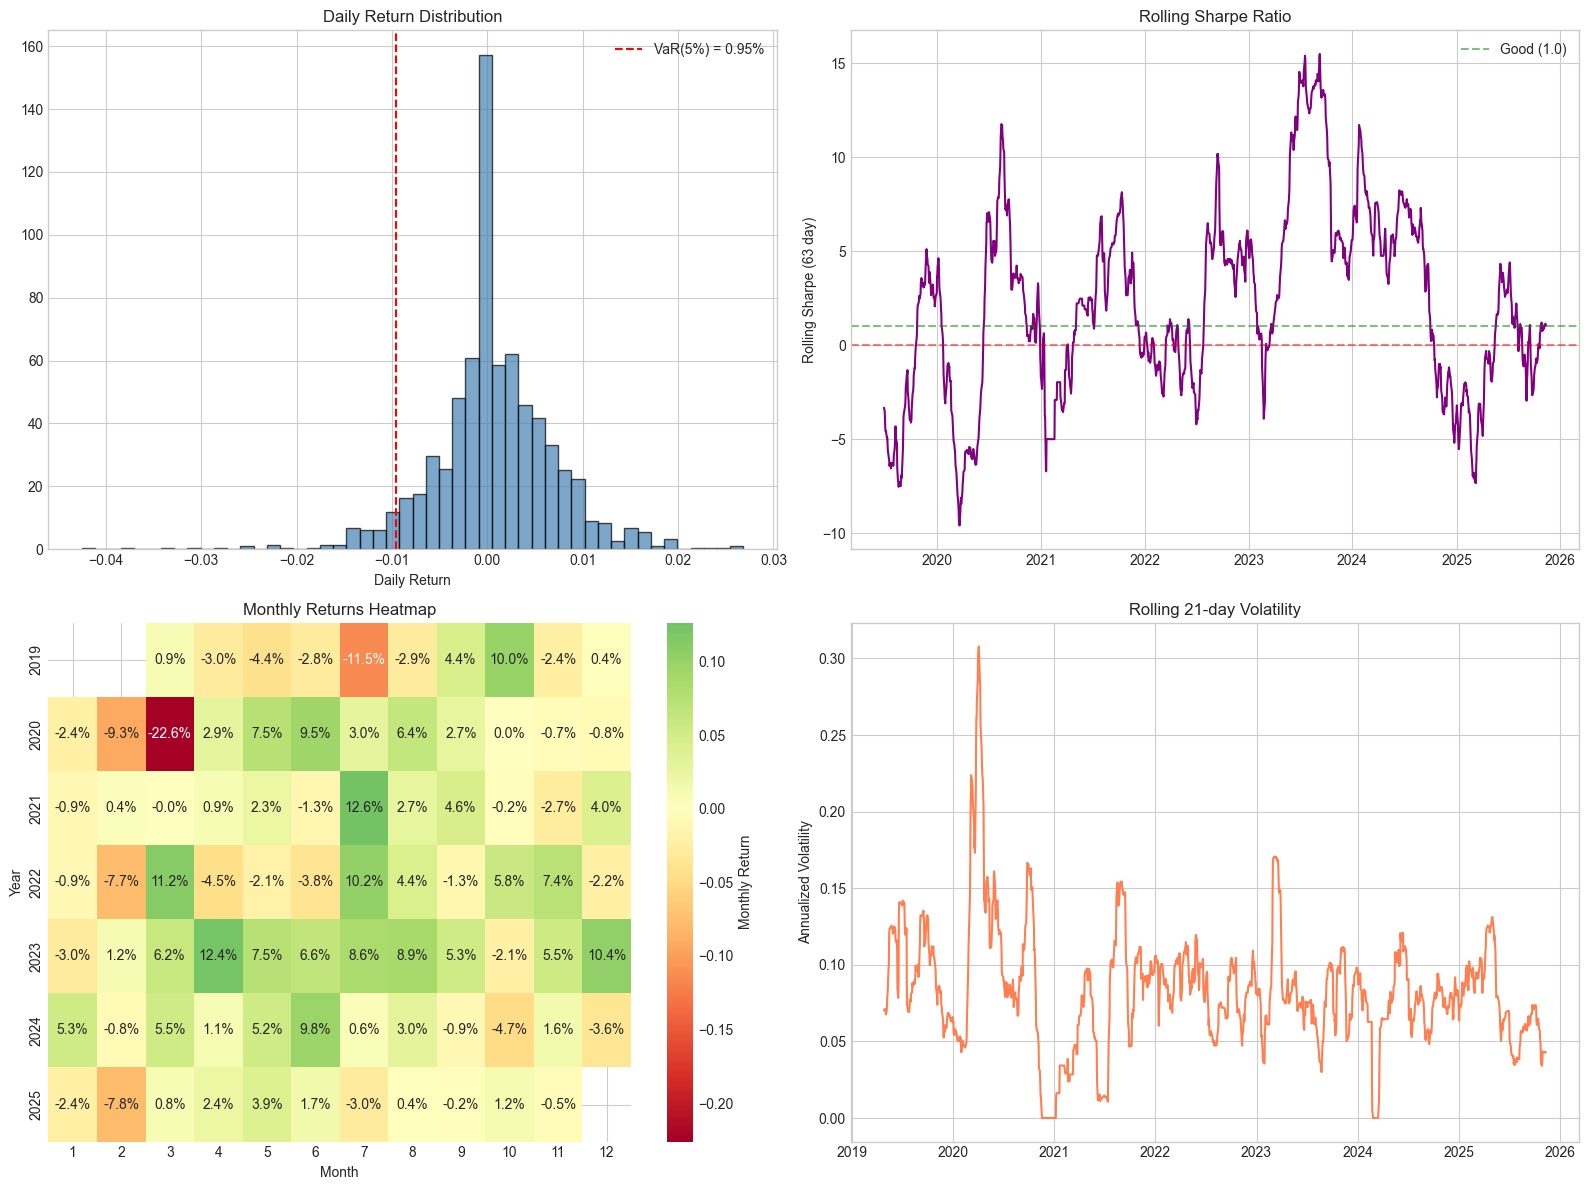

In [10]:
if daily_returns is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Return distribution
    axes[0, 0].hist(portfolio_returns, bins=50, density=True, alpha=0.7,
                     color="steelblue", edgecolor="black")
    var_5 = value_at_risk(portfolio_returns, confidence=0.95)
    axes[0, 0].axvline(-var_5, color="red", linestyle="--", 
                        label=f"VaR(5%) = {var_5:.2%}")
    axes[0, 0].set_xlabel("Daily Return")
    axes[0, 0].set_title("Daily Return Distribution")
    axes[0, 0].legend()
    
    # 2. Rolling Sharpe
    rolling_sharpe = portfolio_returns.rolling(63).apply(
        lambda x: x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else 0
    )
    axes[0, 1].plot(rolling_sharpe.index, rolling_sharpe.values, color="purple")
    axes[0, 1].axhline(0, color="red", linestyle="--", alpha=0.5)
    axes[0, 1].axhline(1, color="green", linestyle="--", alpha=0.5, label="Good (1.0)")
    axes[0, 1].set_ylabel("Rolling Sharpe (63 day)")
    axes[0, 1].set_title("Rolling Sharpe Ratio")
    axes[0, 1].legend()
    
    # 3. Monthly returns heatmap
    monthly = portfolio_returns.resample("ME").apply(lambda x: (1+x).prod()-1)
    monthly_pivot = pd.DataFrame({
        "year": monthly.index.year,
        "month": monthly.index.month,
        "return": monthly.values
    }).pivot(index="year", columns="month", values="return")
    
    sns.heatmap(monthly_pivot, annot=True, fmt=".1%", cmap="RdYlGn",
                center=0, ax=axes[1, 0], cbar_kws={"label": "Monthly Return"})
    axes[1, 0].set_title("Monthly Returns Heatmap")
    axes[1, 0].set_xlabel("Month")
    axes[1, 0].set_ylabel("Year")
    
    # 4. Rolling volatility
    rolling_vol = portfolio_returns.rolling(21).std() * np.sqrt(252)
    axes[1, 1].plot(rolling_vol.index, rolling_vol.values, color="coral")
    axes[1, 1].set_ylabel("Annualized Volatility")
    axes[1, 1].set_title("Rolling 21-day Volatility")
    
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "risk_analytics.png", dpi=150, bbox_inches="tight")
    plt.show()

## Step 4 — Alpha & Beta Analysis

**CAPM**: $E[R_p] = R_f + \beta(E[R_m] - R_f)$

- **Alpha > 0**: We're beating the market (risk-adjusted)
- **Beta = 1**: We move like the market
- **Beta < 1**: Less volatile than market

Alpha: 9.22% (annualized)
Beta:  0.0347

✅ Positive alpha — portfolio generates excess returns!


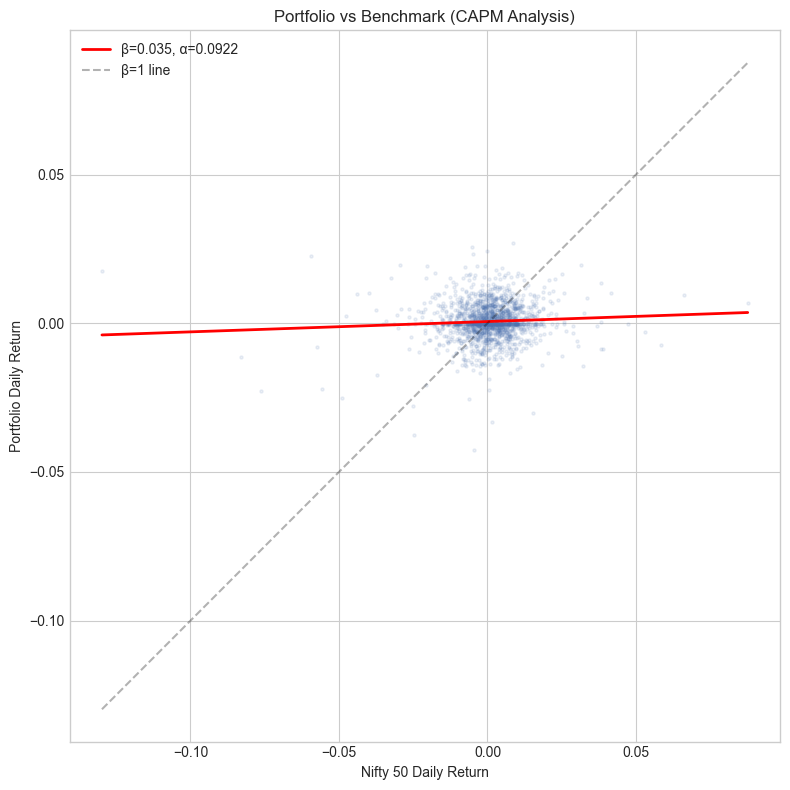

In [11]:
if daily_returns is not None and benchmark_returns is not None:
    beta = compute_beta(portfolio_returns, benchmark_returns)
    alpha = compute_alpha(portfolio_returns, benchmark_returns)
    
    # compute_alpha already returns annualized alpha (uses annualized_return internally)
    print(f"Alpha: {alpha:.2%} (annualized)")
    print(f"Beta:  {beta:.4f}")
    
    if alpha > 0:
        print(f"\n✅ Positive alpha — portfolio generates excess returns!")
    else:
        print(f"\n⚠️ Negative alpha — underperforming risk-adjusted benchmark")
    
    # Scatter plot: portfolio vs benchmark returns
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(benchmark_returns, portfolio_returns, alpha=0.1, s=5)
    
    # Regression line
    z = np.polyfit(benchmark_returns, portfolio_returns, 1)
    p = np.poly1d(z)
    x_line = np.linspace(benchmark_returns.min(), benchmark_returns.max(), 100)
    ax.plot(x_line, p(x_line), "r-", lw=2, label=f"β={beta:.3f}, α={alpha:.4f}")
    ax.plot(x_line, x_line, "k--", alpha=0.3, label="β=1 line")
    
    ax.set_xlabel("Nifty 50 Daily Return")
    ax.set_ylabel("Portfolio Daily Return")
    ax.set_title("Portfolio vs Benchmark (CAPM Analysis)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "alpha_beta_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

## Step 5 — Omega Ratio Deep Dive

The Omega ratio is more comprehensive than Sharpe because it considers
the **entire return distribution**, not just mean and variance.

$$\Omega(\theta) = \frac{\text{Expected gains above } \theta}{\text{Expected losses below } \theta}$$

- Omega > 1: More upside than downside
- Omega > 2: Significantly more upside

Omega Ratio: 1.3171


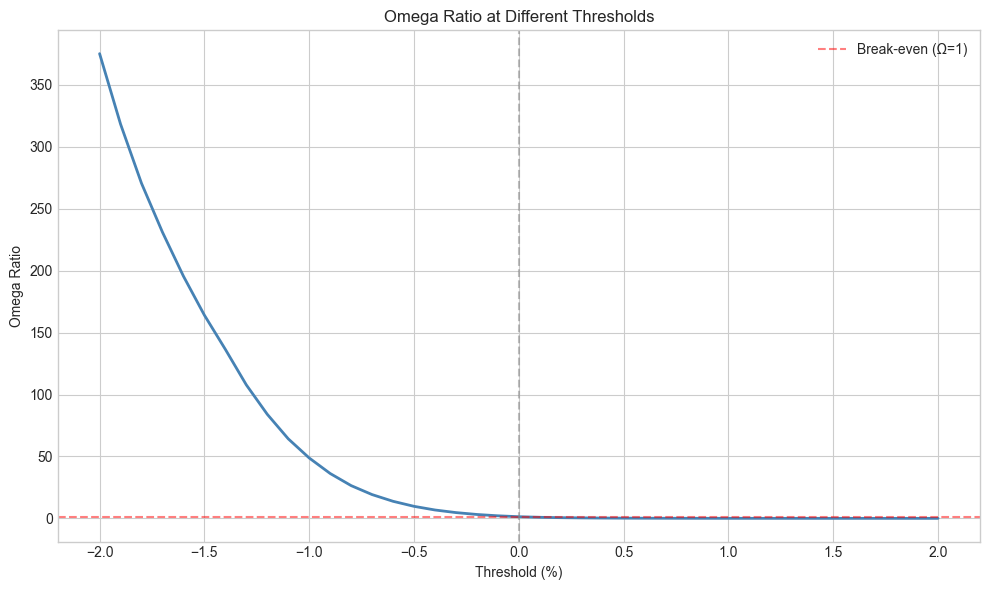

In [12]:
if daily_returns is not None:
    omega = omega_ratio(portfolio_returns)
    print(f"Omega Ratio: {omega:.4f}")
    
    # Compute omega at different thresholds
    thresholds = np.linspace(-0.02, 0.02, 41)
    omegas = [omega_ratio(portfolio_returns, threshold=t) for t in thresholds]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(thresholds * 100, omegas, color="steelblue", lw=2)
    ax.axhline(1, color="red", linestyle="--", alpha=0.5, label="Break-even (Ω=1)")
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Threshold (%)")
    ax.set_ylabel("Omega Ratio")
    ax.set_title("Omega Ratio at Different Thresholds")
    ax.legend()
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "omega_ratio.png", dpi=150, bbox_inches="tight")
    plt.show()

## ✅ Risk Analytics Complete!

**Metrics computed:** Sharpe, Sortino, Alpha, Beta, Omega, Calmar, VaR, CVaR, Max Drawdown

**Next:** Proceed to **Notebook 12 — Daily Capital Allocation Advisor**

---
*Educational project. Not financial advice.*